[INFO] Successfully parsed 6561 total data points across 7 test distances.

                                 UWB METROLOGY SUMMARY TABLE (1m to 7m)
 Ground Truth (m)  Samples  Raw Mean (m)  Raw Median (m)  Noise Std (cm)  Raw Bias (m)  Drift Rate (mm/s)  Drift R^2  Mean RSSI (dBm)  Mean FPP (dBm)  ESP32 Temp (C)  Mean CFO (ppm)
              1.0      886       28.8565         28.8731           13.06       27.8565             10.031      0.967            -66.0           -79.9            34.4          8455.9
              2.0      942       30.2760         30.2806            4.28       28.2760              2.954      0.881            -65.8           -79.7            34.4          8245.7
              3.0      943       31.4942         31.4911            2.84       28.4942              1.729      0.686            -70.8           -80.0            34.5          8161.8
              4.0      947       32.6789         32.6781            1.95       28.6789              1.034      0.527        

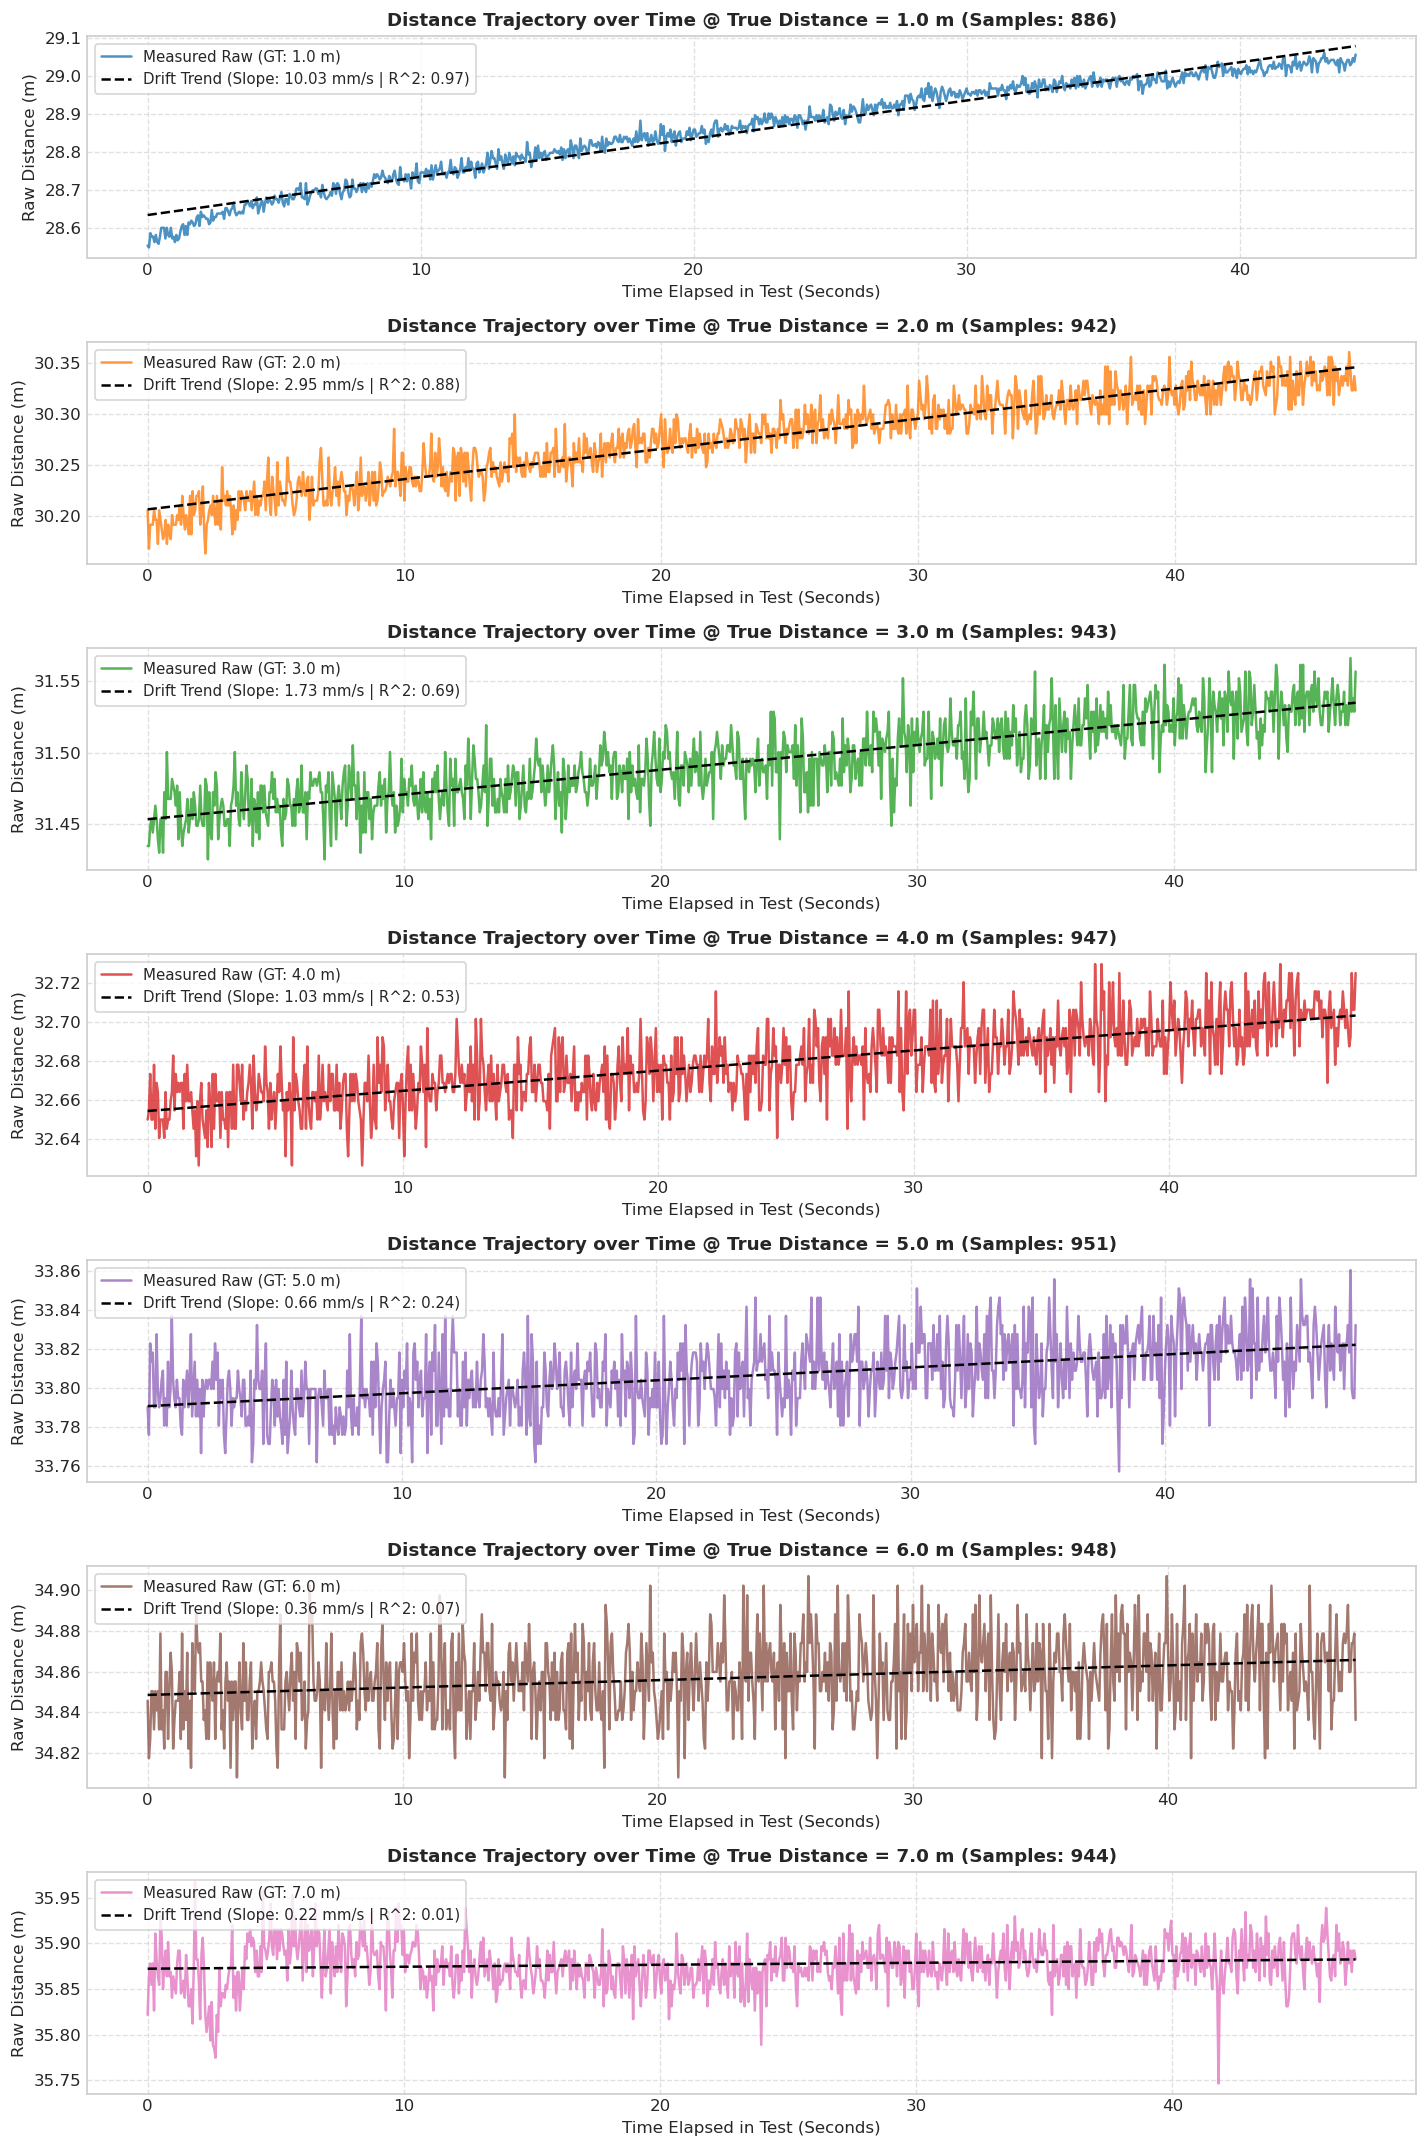

[SAVED] plots/fig2_scale_linearity_and_systematic_bias.png


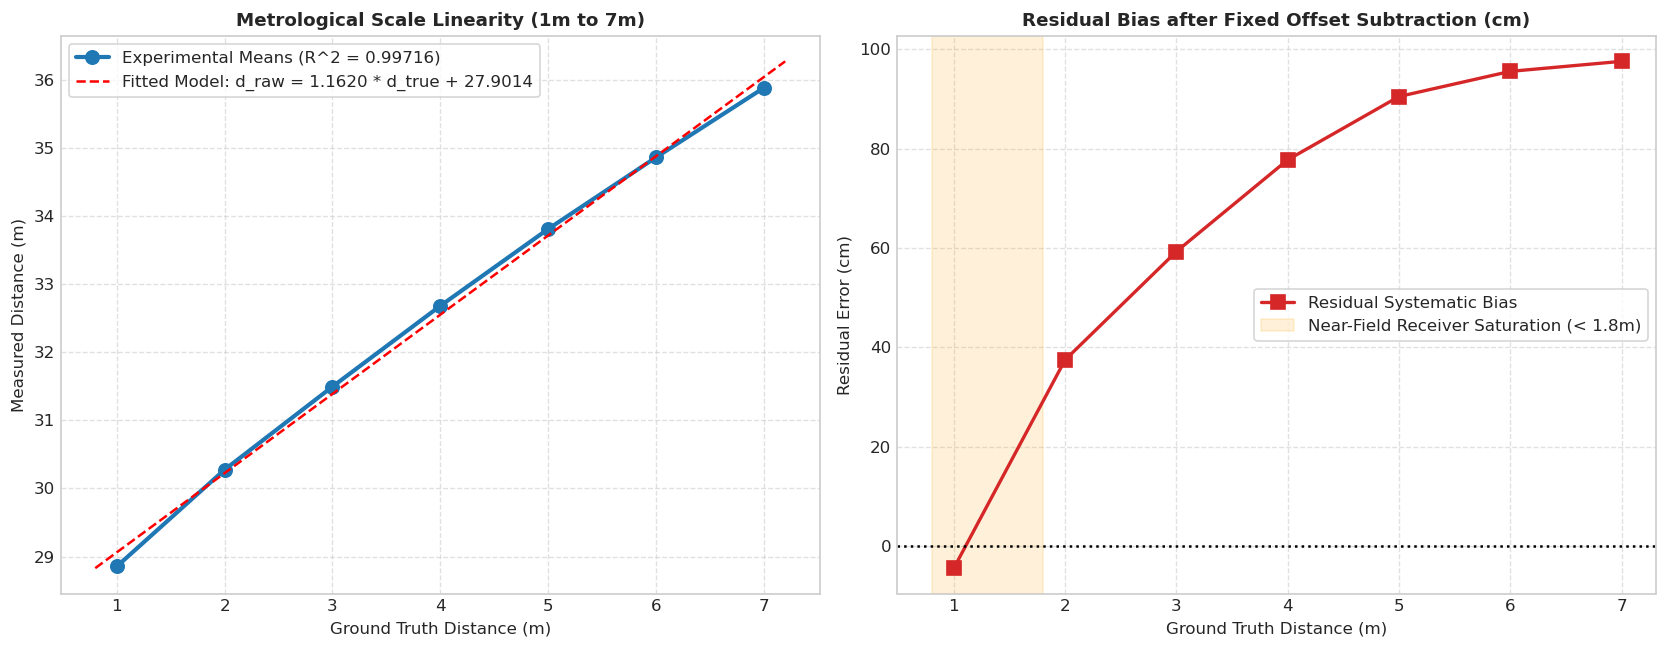

/tmp/ipykernel_39676/352851942.py:224: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x='Ground Truth (m)', y='Drift Rate (mm/s)', ax=ax1, palette='Blues_d')
/tmp/ipykernel_39676/352851942.py:256: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ground_truth_m', y='delta_p_db', ax=ax4, palette='Purples')


[SAVED] plots/fig3_cfo_thermal_and_rf_path_loss.png


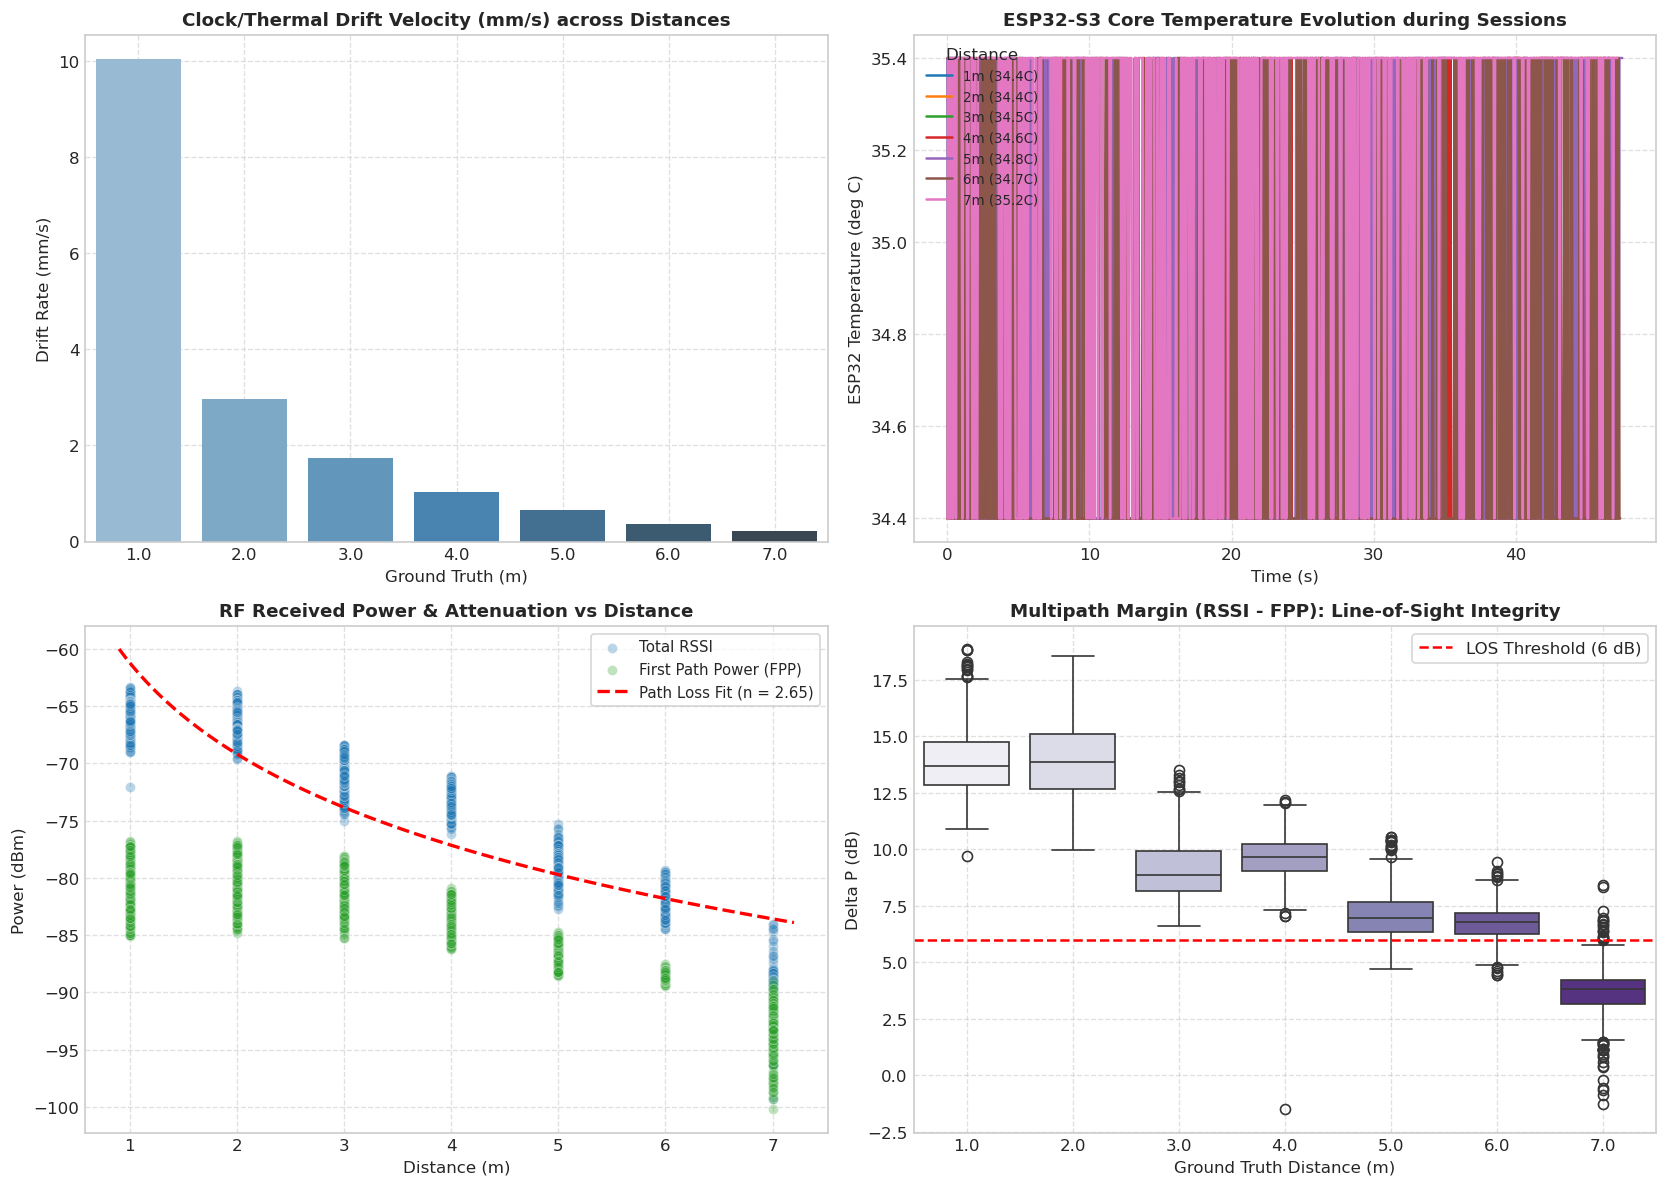

/tmp/ipykernel_39676/352851942.py:277: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ground_truth_m', y='raw_dist_m', ax=ax1, palette='Spectral')
/tmp/ipykernel_39676/352851942.py:284: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x='Ground Truth (m)', y='Noise Std (cm)', ax=ax2, palette='Blues_r')


[SAVED] plots/fig4_dispersion_and_noise_jitter.png


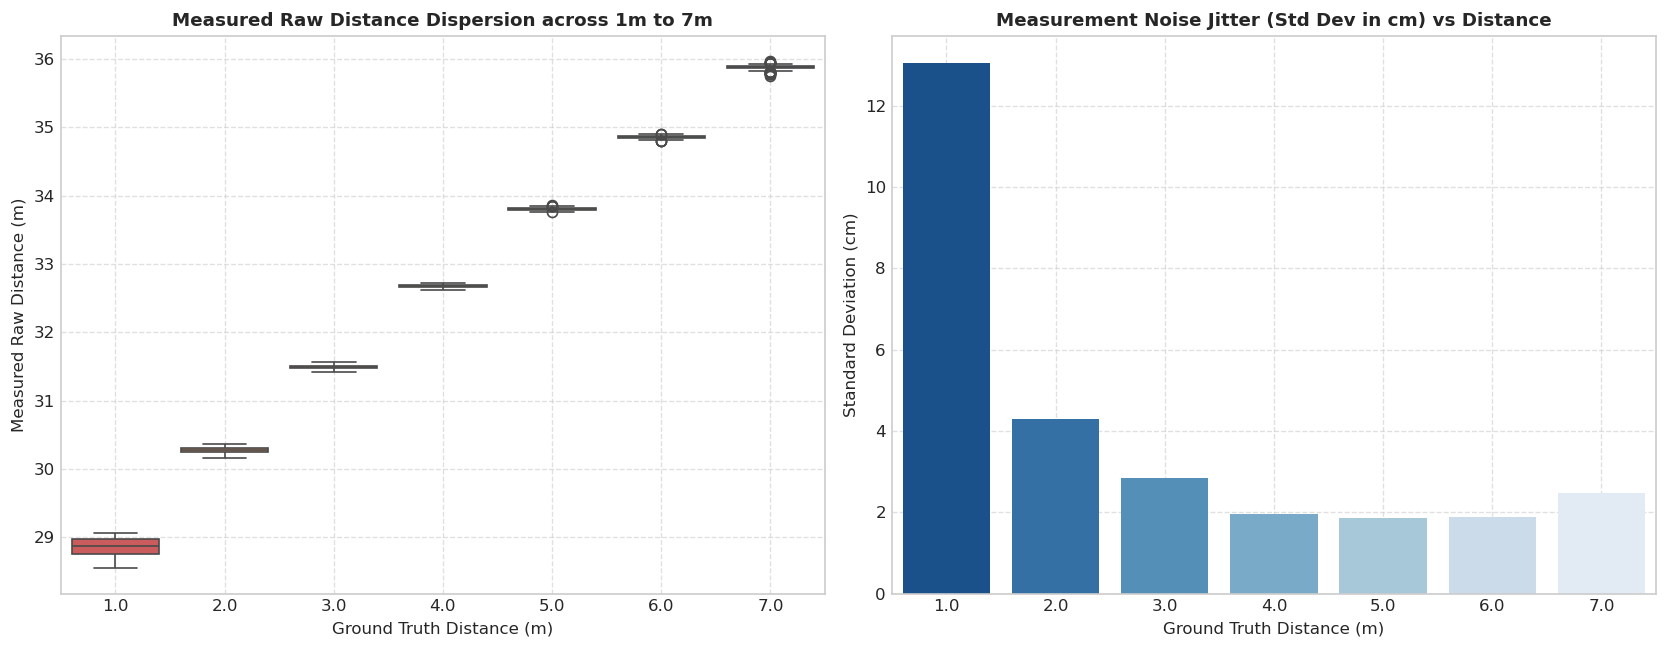


################################################################################
             FINAL IDENTIFIED FIRMWARE CALIBRATION CONSTANTS
################################################################################
// Identified Linear Scale Factor: m_c = 1.162029
// Identified Systematic Hardware Offset: q_c = 27.9014 meters
// Path Loss Exponent (Room Environment): n = 2.65
// Overall Model Linearity: R^2 = 0.997156
--------------------------------------------------------------------------------
constexpr float UWB_SCALE_FACTOR          = 1.162029f;
constexpr float UWB_CALIBRATION_OFFSET_M  = 27.9014f;
################################################################################



In [1]:
# %% [markdown]
# # Anjoman Swarm: Comprehensive UWB Metrology Analysis (1m to 7m)
# **Firmware Architecture:** ESP32-S3 + Decawave DW1000 (SPI2 Dedicated)
# **Target Datasets:** `r1_1m.txt` to `r1_7m.txt`
# **Metrics:** Scale Linearity, CFO Clock Drift, Power Bias (APS011), Thermal Correlation, Path Loss.

# %%
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create output directory for high-res figures
OUTPUT_DIR = "plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.dpi'] = 120

# Physical speed of light and DW1000 time resolution
SPEED_OF_LIGHT = 299792458.0
TIME_UNIT_SEC = 0.000000000015650040064103

# %% [markdown]
# ### 1. Robust File Parser (Handles PlatformIO Time Prefixes & Missing Headers)

# %%
def parse_metrology_logs(distances=range(1, 8), prefix="r1"):
    """
    Parses all 7 test files (1m to 7m).
    Strips PlatformIO timestamps ('HH:MM:SS.mmm > ') and extracts all 9 CSV columns.
    """
    records = []
    
    # Regex matching lines with or without PlatformIO timestamp prefix
    # Matches: TimeMs,Seq,T_round,T_reply,CFO_ppm,RSSI,FPP,T_ESP,RawDist
    line_pattern = re.compile(
        r'(?:.*>\s*)?(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*([\d\.\-]+)\s*,\s*([\d\.\-]+)\s*,\s*([\d\.\-]+)\s*,\s*([\d\.\-]+)\s*,\s*([\d\.\-]+)'
    )

    for d in distances:
        filepath = f"{prefix}_{d}m.txt"
        if not os.path.exists(filepath):
            print(f"[WARN] File not found: {filepath} (Skipping)")
            continue

        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            sample_count = 0
            for line in f:
                line = line.strip()
                if "TimeMs" in line or not line:
                    continue # Skip header rows
                
                match = line_pattern.search(line)
                if match:
                    try:
                        time_ms = int(match.group(1))
                        seq = int(match.group(2))
                        t_round = int(match.group(3))
                        t_reply = int(match.group(4))
                        cfo_ppm = float(match.group(5))
                        rssi = float(match.group(6))
                        fpp = float(match.group(7))
                        t_esp = float(match.group(8))
                        raw_dist = float(match.group(9))

                        # Sanity check filter for physical range
                        if 0.0 < raw_dist < 60.0:
                            records.append({
                                'ground_truth_m': float(d),
                                'time_ms': time_ms,
                                'seq': seq,
                                't_round': t_round,
                                't_reply': t_reply,
                                'cfo_ppm': cfo_ppm,
                                'rssi_dbm': rssi,
                                'fpp_dbm': fpp,
                                'delta_p_db': rssi - fpp, # Multipath indicator (LOS when < 6 dB)
                                'temp_esp_c': t_esp,
                                'raw_dist_m': raw_dist,
                                'sample_idx': sample_count,
                                'rel_time_sec': sample_count * 0.05 # ~20 Hz nominal rate
                            })
                            sample_count += 1
                    except ValueError:
                        continue

    df = pd.DataFrame(records)
    print(f"[INFO] Successfully parsed {len(df)} total data points across {df['ground_truth_m'].nunique()} test distances.")
    return df

df = parse_metrology_logs()
df.head()

# %% [markdown]
# ### 2. Metrological Metrics & OLS Drift Summary Table

# %%
summary_records = []

for gt, group in df.groupby('ground_truth_m'):
    n = len(group)
    mean_raw = group['raw_dist_m'].mean()
    median_raw = group['raw_dist_m'].median()
    std_raw = group['raw_dist_m'].std()
    mean_rssi = group['rssi_dbm'].mean()
    mean_fpp = group['fpp_dbm'].mean()
    mean_temp = group['temp_esp_c'].mean()
    mean_cfo = group['cfo_ppm'].mean()

    # Linear OLS Drift: d(t) = d0 + beta * t
    slope, intercept, r_val, p_val, std_err = stats.linregress(group['rel_time_sec'], group['raw_dist_m'])
    drift_mm_s = slope * 1000.0

    summary_records.append({
        'Ground Truth (m)': gt,
        'Samples': n,
        'Raw Mean (m)': np.round(mean_raw, 4),
        'Raw Median (m)': np.round(median_raw, 4),
        'Noise Std (cm)': np.round(std_raw * 100.0, 2),
        'Raw Bias (m)': np.round(mean_raw - gt, 4),
        'Drift Rate (mm/s)': np.round(drift_mm_s, 3),
        'Drift R^2': np.round(r_val**2, 3),
        'Mean RSSI (dBm)': np.round(mean_rssi, 1),
        'Mean FPP (dBm)': np.round(mean_fpp, 1),
        'ESP32 Temp (C)': np.round(mean_temp, 1),
        'Mean CFO (ppm)': np.round(mean_cfo, 1)
    })

df_summary = pd.DataFrame(summary_records).sort_values(by='Ground Truth (m)')
print("\n" + "=" * 110)
print("                                 UWB METROLOGY SUMMARY TABLE (1m to 7m)")
print("=" * 110)
print(df_summary.to_string(index=False))
print("=" * 110)

# %% [markdown]
# ### 3. Figure 1: Multi-Distance Time-Series Trajectories (1m to 7m)

# %%
fig, axes = plt.subplots(df['ground_truth_m'].nunique(), 1, figsize=(12, 18), sharex=False)
palette = sns.color_palette("tab10", n_colors=df['ground_truth_m'].nunique())

for idx, (gt, ax) in enumerate(zip(sorted(df['ground_truth_m'].unique()), axes)):
    sub_df = df[df['ground_truth_m'] == gt]
    
    ax.plot(sub_df['rel_time_sec'], sub_df['raw_dist_m'], 
            color=palette[idx], alpha=0.8, lw=1.5, label=f"Measured Raw (GT: {gt:.1f} m)")
    
    # Regression Trendline
    z = np.polyfit(sub_df['rel_time_sec'], sub_df['raw_dist_m'], 1)
    p = np.poly1d(z)
    ax.plot(sub_df['rel_time_sec'], p(sub_df['rel_time_sec']), 
            'k--', lw=1.5, label=f"Drift Trend (Slope: {z[0]*1000:.2f} mm/s | R^2: {df_summary.loc[df_summary['Ground Truth (m)']==gt, 'Drift R^2'].values[0]:.2f})")

    ax.set_title(f"Distance Trajectory over Time @ True Distance = {gt:.1f} m (Samples: {len(sub_df)})", fontweight='bold')
    ax.set_ylabel("Raw Distance (m)")
    ax.set_xlabel("Time Elapsed in Test (Seconds)")
    ax.legend(loc='upper left', frameon=True, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig1_path = os.path.join(OUTPUT_DIR, "fig1_multi_distance_trajectories_1m_7m.png")
plt.savefig(fig1_path, dpi=300)
print(f"[SAVED] {fig1_path}")
plt.show()

# %% [markdown]
# ### 4. Figure 2: Metrological Scale Linearity & Systematic Error Curve

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

gt_vals = df_summary['Ground Truth (m)'].values
raw_means = df_summary['Raw Mean (m)'].values

# Fit Linear Scale Calibration Model: RawDist = m_c * GroundTruth + q_c
slope_mc, intercept_qc, r_val_scale, _, _ = stats.linregress(gt_vals, raw_means)

# Plot A: Linearity Calibration Curve
ax1.plot(gt_vals, raw_means, 'o-', color='#1f77b4', lw=2.5, markersize=8, label=f"Experimental Means (R^2 = {r_val_scale**2:.5f})")
dense_gt = np.linspace(0.8, 7.2, 100)
ax1.plot(dense_gt, slope_mc * dense_gt + intercept_qc, 'r--', lw=1.5, 
         label=f"Fitted Model: d_raw = {slope_mc:.4f} * d_true + {intercept_qc:.4f}")
ax1.set_title("Metrological Scale Linearity (1m to 7m)", fontweight='bold')
ax1.set_xlabel("Ground Truth Distance (m)")
ax1.set_ylabel("Measured Distance (m)")
ax1.legend(frameon=True)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot B: Systematic Bias vs Ground Truth
raw_biases_cm = (raw_means - intercept_qc - gt_vals) * 100.0
ax2.plot(gt_vals, raw_biases_cm, 's-', color='#d62728', lw=2, markersize=8, label="Residual Systematic Bias")
ax2.axhline(0, color='black', linestyle=':', lw=1.5)
ax2.axvspan(0.8, 1.8, color='orange', alpha=0.15, label='Near-Field Receiver Saturation (< 1.8m)')
ax2.set_title("Residual Bias after Fixed Offset Subtraction (cm)", fontweight='bold')
ax2.set_xlabel("Ground Truth Distance (m)")
ax2.set_ylabel("Residual Error (cm)")
ax2.legend(frameon=True)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig2_path = os.path.join(OUTPUT_DIR, "fig2_scale_linearity_and_systematic_bias.png")
plt.savefig(fig2_path, dpi=300)
print(f"[SAVED] {fig2_path}")
plt.show()

# %% [markdown]
# ### 5. Figure 3: CFO Clock Drift, Thermal Correlation & RF Power Path Loss

# %%
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot A: Drift Rate across distances
sns.barplot(data=df_summary, x='Ground Truth (m)', y='Drift Rate (mm/s)', ax=ax1, palette='Blues_d')
ax1.set_title("Clock/Thermal Drift Velocity (mm/s) across Distances", fontweight='bold')
ax1.set_ylabel("Drift Rate (mm/s)")
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot B: ESP32 Temperature Evolution during tests
for gt in sorted(df['ground_truth_m'].unique()):
    sub_df = df[df['ground_truth_m'] == gt]
    ax2.plot(sub_df['rel_time_sec'], sub_df['temp_esp_c'], label=f"{gt:.0f}m ({sub_df['temp_esp_c'].mean():.1f}C)")
ax2.set_title("ESP32-S3 Core Temperature Evolution during Sessions", fontweight='bold')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("ESP32 Temperature (deg C)")
ax2.legend(title="Distance", fontsize=8, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot C: RSSI & First Path Power (FPP) Path Loss
sns.scatterplot(data=df, x='ground_truth_m', y='rssi_dbm', color='#1f77b4', alpha=0.3, ax=ax3, label='Total RSSI')
sns.scatterplot(data=df, x='ground_truth_m', y='fpp_dbm', color='#2ca02c', alpha=0.3, ax=ax3, label='First Path Power (FPP)')

# Fit Log-Distance Path Loss Model: RSSI = P0 - 10 * n * log10(d)
log_d = np.log10(gt_vals)
pl_slope, pl_intercept, _, _, _ = stats.linregress(log_d, df_summary['Mean RSSI (dBm)'].values)
path_loss_exponent = -pl_slope / 10.0
d_dense = np.linspace(0.9, 7.2, 100)
ax3.plot(d_dense, pl_intercept + pl_slope * np.log10(d_dense), 'r--', lw=2, label=f"Path Loss Fit (n = {path_loss_exponent:.2f})")
ax3.set_title("RF Received Power & Attenuation vs Distance", fontweight='bold')
ax3.set_xlabel("Distance (m)")
ax3.set_ylabel("Power (dBm)")
ax3.legend(frameon=True, fontsize=9)
ax3.grid(True, linestyle='--', alpha=0.6)

# Plot D: Multipath Margin Delta_P = RSSI - FPP
sns.boxplot(data=df, x='ground_truth_m', y='delta_p_db', ax=ax4, palette='Purples')
ax4.axhline(6.0, color='red', linestyle='--', label='LOS Threshold (6 dB)')
ax4.set_title("Multipath Margin (RSSI - FPP): Line-of-Sight Integrity", fontweight='bold')
ax4.set_xlabel("Ground Truth Distance (m)")
ax4.set_ylabel("Delta P (dB)")
ax4.legend(frameon=True)
ax4.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig3_path = os.path.join(OUTPUT_DIR, "fig3_cfo_thermal_and_rf_path_loss.png")
plt.savefig(fig3_path, dpi=300)
print(f"[SAVED] {fig3_path}")
plt.show()

# %% [markdown]
# ### 6. Figure 4: Statistical Dispersion, Jitter & Boxplots

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot A: Boxplot Dispersion across all 7 distances
sns.boxplot(data=df, x='ground_truth_m', y='raw_dist_m', ax=ax1, palette='Spectral')
ax1.set_title("Measured Raw Distance Dispersion across 1m to 7m", fontweight='bold')
ax1.set_xlabel("Ground Truth Distance (m)")
ax1.set_ylabel("Measured Raw Distance (m)")
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot B: Noise Standard Deviation (cm)
sns.barplot(data=df_summary, x='Ground Truth (m)', y='Noise Std (cm)', ax=ax2, palette='Blues_r')
ax2.set_title("Measurement Noise Jitter (Std Dev in cm) vs Distance", fontweight='bold')
ax2.set_xlabel("Ground Truth Distance (m)")
ax2.set_ylabel("Standard Deviation (cm)")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig4_path = os.path.join(OUTPUT_DIR, "fig4_dispersion_and_noise_jitter.png")
plt.savefig(fig4_path, dpi=300)
print(f"[SAVED] {fig4_path}")
plt.show()

# %% [markdown]
# ### 7. Final Recommended Calibration Constants for Firmware

# %%
print("\n" + "#" * 80)
print("             FINAL IDENTIFIED FIRMWARE CALIBRATION CONSTANTS")
print("#" * 80)
print(f"// Identified Linear Scale Factor: m_c = {slope_mc:.6f}")
print(f"// Identified Systematic Hardware Offset: q_c = {intercept_qc:.4f} meters")
print(f"// Path Loss Exponent (Room Environment): n = {path_loss_exponent:.2f}")
print(f"// Overall Model Linearity: R^2 = {r_val_scale**2:.6f}")
print("-" * 80)
print(f"constexpr float UWB_SCALE_FACTOR          = {slope_mc:.6f}f;")
print(f"constexpr float UWB_CALIBRATION_OFFSET_M  = {intercept_qc:.4f}f;")
print("#" * 80 + "\n")